# Big Data Project - ImageRecommender
## Pattern Recognition 
Code and Dokumentation
(allg, für folgenden code wurden nur 34 Bilder genutzt um zu testen welche Modelle wie gut performen, anschließend wurde nochmal mit einem Bild aus den 34 Bildern getestet + 2 unbekannte Bilder getestet wie gut die Pipeline funktioniert)

### Pattern Recognition - Goal:
one measure that used compressed image embeddings (using deep learning model)
Ziel ist eine Methode, die Bilder anhand ihres Inhaltes (Motiv/Muster) vergleicht und angibt wie ähnlich sich zwei dieser Bilder sind.
wobei die Berechnung der Ähnlichkeit eigentlich ausgelagert ist, nur hier zur Vollständigkeit und Vergleichbarkeit der Modele vorhanden ist.


### What are Embeddings?
https://www.ibm.com/de-de/think/topics/embedding <br>
https://www.picsellia.com/post/image-embeddings-explained

Embeddings sind Mittel zur Darstellung von Objekten wie Text, Bildern oder Audio als Punkte in einem kontinuierlichen Vektorraum. Sie reduzieren den Input (z. B. Pixel) zu einem Vektor, der die wichtigsten Eigenschaften des Objekts enthält. Im Gegensatz zu einer expliziten Objektliste speichert ein Embedding keine direkten Kategorien, sondern abstrakte Merkmalskombinationen. In unserem Fall nutzen wir diesen Zwischenvektor, ohne Klassifikation, um die Ähnlichkeit zwischen den Mustern/Motiven der Bildern zu berechnen.

### Model Auswahl
https://tobiasvanderwerff.com/2024/05/15/cnn-vs-vit.html <br>
https://github.com/AlhaririAnas/Image-recommender/blob/main/Dokumentation.pdf <br>
https://github.com/miriam-agrawala/Image_Recommender_2023/blob/main/Dokumentation_Project_Image_Recommender.pdf <br>
Chat GPT o5 "aus 500000 Bildern soll für ein neues BIld die 5 ähnlichsten Bilder anhand von Pattern recognition ausgewählt werden.
was ist hier der unterschied zwischen CNN und VIT und welche modelle würdest du mir empfehlen wenn die berechnungen möglichst schnell sein soll"
 <br> <br>

Mit der Recherche (u.a. auch mit ChatGPT und Dokumentationen des Projektes aus den vorherigen Semesters), wurde klar, dass viele Modelle zur Auswahl stehen und diese unterschiedliche Vor- und Nachteile haben. 
Zum einen ob wir ein einfaches CNN verwenden oder einen Visual Transformer, und dann welches Model genau.

#### Unterschied ViT (Visual Transformer ) vs. CNN
https://huggingface.co/docs/transformers/model_doc/vit
image (https://arxiv.org/pdf/2010.11929)
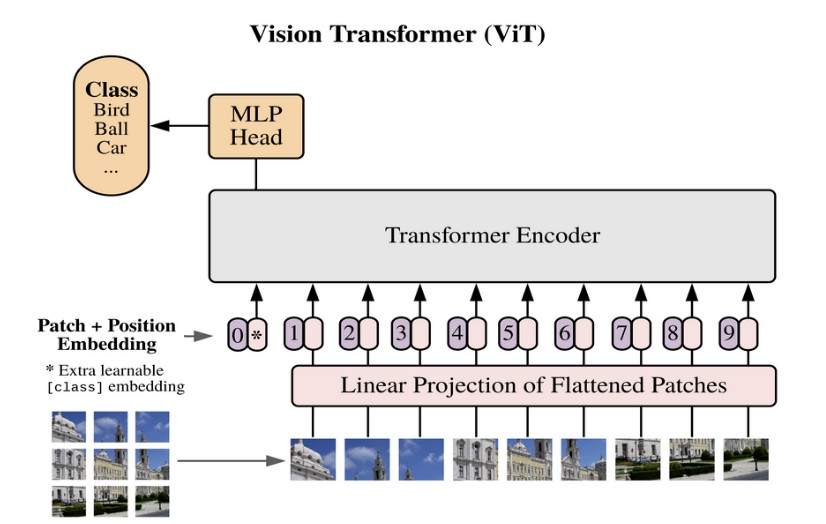
 <br> <br>



ViT ermöglichen es, den globalen Kontext eines Bildes zu erfassen, anstatt nur lokale Merkmale zu erkennen.
Zu Beginn wird das Bild in gleich große Patches zerlegt. Jeder dieser Patches wird wie ein Token in der NLP-Verarbeitung behandelt. Durch Self-Attention kann jeder Patch auf alle anderen Patches „schauen“, wodurch semantische Zusammenhänge erkannt werden.
Beispiel: Es werden nicht nur einzelne Objekte wie Rad, Sattel und Lenker erkannt, sondern das Modell versteht, dass diese zusammen ein Fahrrad ergeben.

Positionsinformationen (Positional Encodings) sorgen dafür, dass die räumliche Anordnung berücksichtigt wird. Das resultierende CLS-Token dient als kompaktes Embedding für Bildinhalte.

CNNs hingegen sind stark auf lokale Muster und Texturen optimiert. Die Faltungsoperation nimmt an:

- Lokale Nachbarschaftsbeziehungen: nahe Pixel sind meist miteinander verbunden
- Gewichtsteilung: dieselben Filter können auf allen Bildbereichen angewendet werden

Diese Inductive Biases (eingebaute Annahmen) helfen CNNs, auch mit relativ kleinen Datensätzen gut zu lernen.
Transformers besitzen hingegen nur wenige solcher Annahmen und müssen mehr direkt aus den Daten lernen. Das erfordert größere Trainingsmengen. Mit genügend Daten können ViTs CNNs übertreffen, schneiden aber bei kleineren Datensätzen oft schlechter ab.

    Hinweis: Theoretisch lassen sich CNNs und ViTs auch kombinieren, um sowohl lokale Muster als auch globale Kontextinformationen zu erfassen. Für unsere aktuelle Anwendung konzentrieren wir uns jedoch auf reine ViT- oder CNN-basierte Feature-Extraktion.

Übersicht der getesteten Modele
(laut chatGPT)

| Modell                  | Typ | Speed (relativ) | Embedding-Qualität (relativ) | Stärken                           | Schwächen                                  |
| ----------------------- | --- | --------------- | ---------------------------- | --------------------------------- | ------------------------------------------ |
| **MobileNetV3-Large**   | CNN | 🚀 Sehr schnell | Mittel                       | Sehr leicht, auch CPU-tauglich    | Weniger präzise bei feinen Details         |
| **EfficientNet-B0**     | CNN | 🚀 Sehr schnell | Hoch                         | Gutes Speed-Accuracy-Verhältnis   | Nicht ganz SOTA-Genauigkeit                |
| **ResNet-50**           | CNN | ⚡ Schnell       | Hoch                         | Bewährte Architektur, robust      | Größer als MobileNet/EfficientNet-B0       |
| **DINOv2**              | ViT | ⚡ Schnell       | Sehr hoch                    | Self-Supervised, starke Features  | Relativ neu, evtl. geringere Verfügbarkeit |
| **Swin-Tiny (swin\_t)** | ViT | ⚡ Schnell       | Hoch bis sehr hoch           | Lokale & globale Kontextinfos     | Komplexere Architektur                     |
| **ViT-B/16**            | ViT | 🐢 Langsam      | Sehr hoch                    | Beste globale Kontextmodellierung | Hoher Rechen- und Speicherbedarf           |


Ausgewählt habe ich diese modele zum einen da sie in vergangen Projekten genutzt wurden (mobileNet, ResNet) und anhand der Vorschläge von ChatGPT.


Um genau festzustellen welches Model am geeignetsten ist werden für alle modelle die gleiche Pipeline erstellt:
(Bilder werden davor geladen)
- für die 30 Bilder im dummy folder werden jeweils die Embeddings berechnet, diese dann reduziert 
- anschließend wird dann zweimal die Ähnlichkeit mit verschiednen Metriken bestimmt ( CosineSimilarity und ) 
- alle diese ähnlichkeiten werden als Matrix gespeichert und als Heatmap geplottet um schnell unterschiede erkennen zu können.

# CODE

### Libraries

In [56]:
from PIL import Image
import urllib
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import transforms
import time

### Load Images + method for preprocessing

In [57]:
image_folder = "images_/" # has to be adjusted obviously if folder is called different...
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

In [58]:
def get_preprocess(model_name):
    if model_name == 'vit_base_patch14_dinov2':
        size = 518
    else:
        size = 224
    return transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])


### Similarity Meassures
adjusted from color similarity to pattern similarity

In [59]:
def cosine_similarity(a, b):
    a_norm = a / np.linalg.norm(a)
    b_norm = b / np.linalg.norm(b)
    return np.dot(a_norm, b_norm)


def euclidean_similarity(a, b):
    dist = np.linalg.norm(a - b)
    # Beispielhafte Transformation in Similarity:
    similarity = 1 / (1 + dist)  # oder
    # similarity = np.exp(-dist)
    return similarity

def calculate_similarity(embeddings, idx1, idx2, metric='cosine'):
    a = embeddings[idx1]
    b = embeddings[idx2]
    if metric == 'cosine':
        return cosine_similarity(a, b)
    elif metric == 'euclidean':
        return euclidean_similarity(a, b)
    else:
        raise ValueError(f"Unsupported metric: {metric}")


### erstellen der Similarity Matrix + Heatmap

In [60]:
def calculate_and_visualize_similarity_matrix(embeddings, image_names, metric='cosine'):
    n = len(embeddings)
    sim_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if metric == 'cosine':
                sim_matrix[i, j] = cosine_similarity(embeddings[i], embeddings[j])
            elif metric == 'euclidean':
                sim_matrix[i, j] = euclidean_similarity(embeddings[i], embeddings[j])
            else:
                raise ValueError(f"Unsupported metric: {metric}")
    
    df = pd.DataFrame(sim_matrix, index=image_names, columns=image_names)
    sns.heatmap(df, cmap="viridis", vmin=0, vmax=1)  # Werte in [0,1]
    plt.title(f"Similarity Matrix ({metric})")
    plt.show()


# whole Pipeline

In [61]:
import torch
import torchvision.models as models
import timm

In [62]:
def extract_embedding_resnet(model, x):
    # ResNet-50 hat keine 'features', aber diese Vorgehensweise funktioniert:
    x = model.conv1(x)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)

    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)

    x = model.avgpool(x)  # Global average pooling (Shape: [batch, 2048, 1, 1])
    embedding = torch.flatten(x, 1)  # Shape: [batch, 2048]
    return embedding


In [63]:
def extract_embedding(model_name, model, input_tensor):
    model.eval()
    with torch.no_grad():
        if model_name in ['mobilenet_v3_large', 'efficientnet_b0']:
            features = model.features(input_tensor)
            embedding = torch.nn.functional.adaptive_avg_pool2d(features, 1).view(input_tensor.size(0), -1)
        elif model_name == 'resnet50':
            embedding = extract_embedding_resnet(model, input_tensor)
        else:
            if hasattr(model, 'forward_features'):
                features = model.forward_features(input_tensor)
            else:
                features = model(input_tensor)
            if features.dim() == 3:
                embedding = features[:, 0]
            else:
                embedding = features.mean(dim=(-2, -1))
    return embedding.cpu().numpy()[0]


In [ ]:
def run_pipeline_for_model(model_name, image_files, image_folder):
    timings = {
        'model': [],
        'step': [],
        'duration_sec': []
    }

    # Modell laden
    t0 = time.perf_counter()
    if model_name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(pretrained=True)
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(pretrained=True)
    elif model_name == 'resnet50':
        model = models.resnet50(pretrained=True)
    elif model_name == 'vit_base_patch14_dinov2':
        model = timm.create_model('vit_base_patch14_dinov2', pretrained=True)
    elif model_name == 'swin_tiny':
        model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True)
    elif model_name == 'vit_b16':
        model = timm.create_model('vit_base_patch16_224', pretrained=True)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    model.eval()
    t1 = time.perf_counter()
    timings['model'].append(model_name)
    timings['step'].append('model_load')
    timings['duration_sec'].append(t1 - t0)

    preprocess = get_preprocess(model_name)
    
    embeddings = []
    image_names = []

    for img_file in image_files:
        # Bild laden + preprocess messen
        t0 = time.perf_counter()
        img_path = os.path.join(image_folder, img_file)
        img = Image.open(img_path).convert("RGB")
        input_tensor = preprocess(img).unsqueeze(0)  # Kein .to(device), CPU
        t1 = time.perf_counter()
        timings['model'].append(model_name)
        timings['step'].append('image_load_and_preprocess')
        timings['duration_sec'].append(t1 - t0)

        # Embedding extrahieren messen
        t0 = time.perf_counter()
        with torch.no_grad():
            embedding = extract_embedding(model_name, model, input_tensor)
        t1 = time.perf_counter()
        timings['model'].append(model_name)
        timings['step'].append('embedding_extract')
        timings['duration_sec'].append(t1 - t0)

        embeddings.append(embedding)
        image_names.append(img_file)

    # Similarity matrix berechnen + messen
    t0 = time.perf_counter()
    calculate_and_visualize_similarity_matrix(embeddings, image_names, metric='cosine')
    t1 = time.perf_counter()
    timings['model'].append(model_name)
    timings['step'].append('similarity_matrix_and_visualization')
    timings['duration_sec'].append(t1 - t0)

    return pd.DataFrame(timings)


--- Pipeline für vit_base_patch14_dinov2 ---


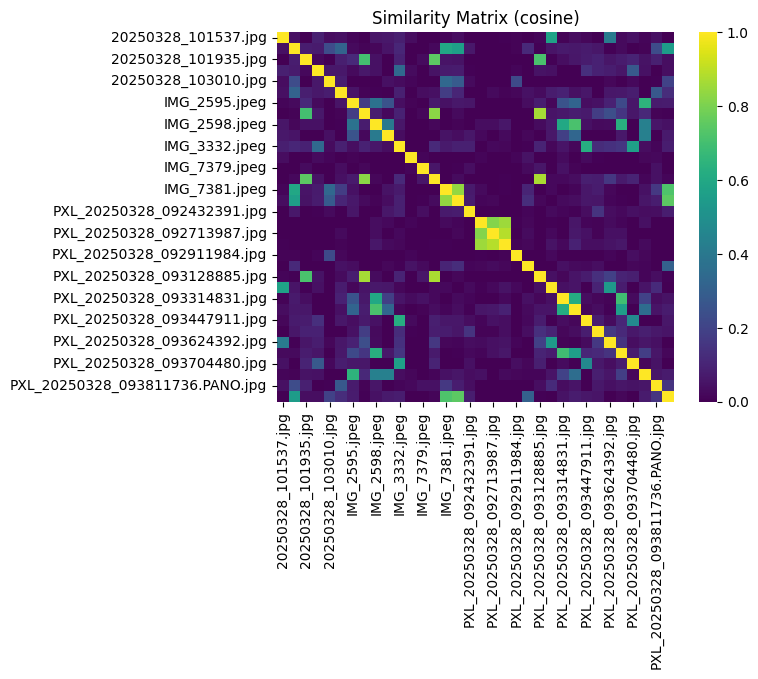

--- Pipeline für swin_tiny ---


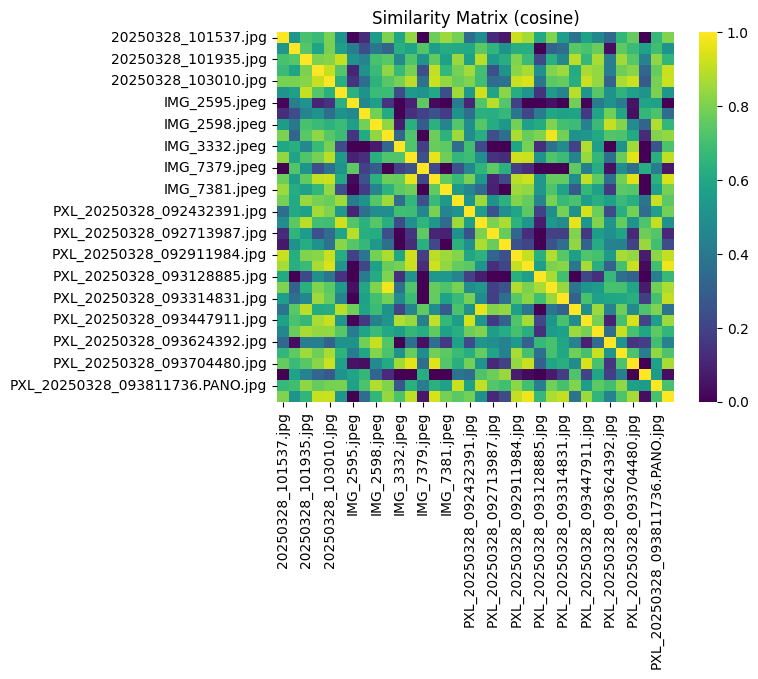

--- Pipeline für vit_b16 ---


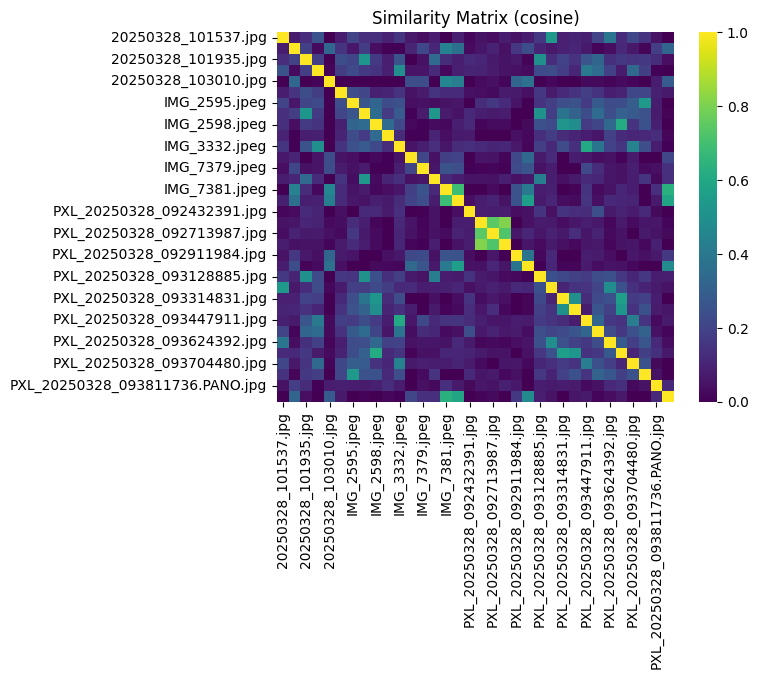

--- Pipeline für mobilenet_v3_large ---


C:\Users\goebe\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\goebe\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


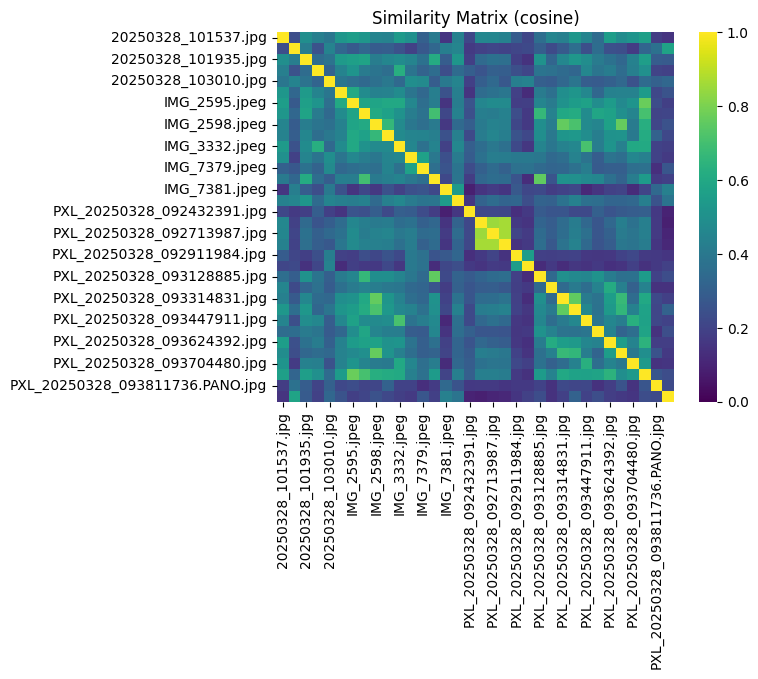

--- Pipeline für efficientnet_b0 ---


C:\Users\goebe\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\goebe\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


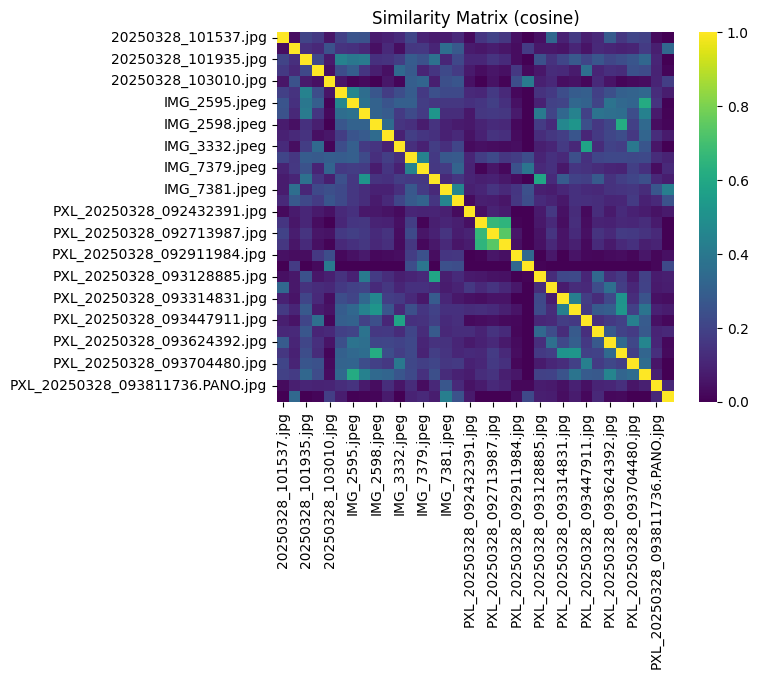

--- Pipeline für resnet50 ---


C:\Users\goebe\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\goebe\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


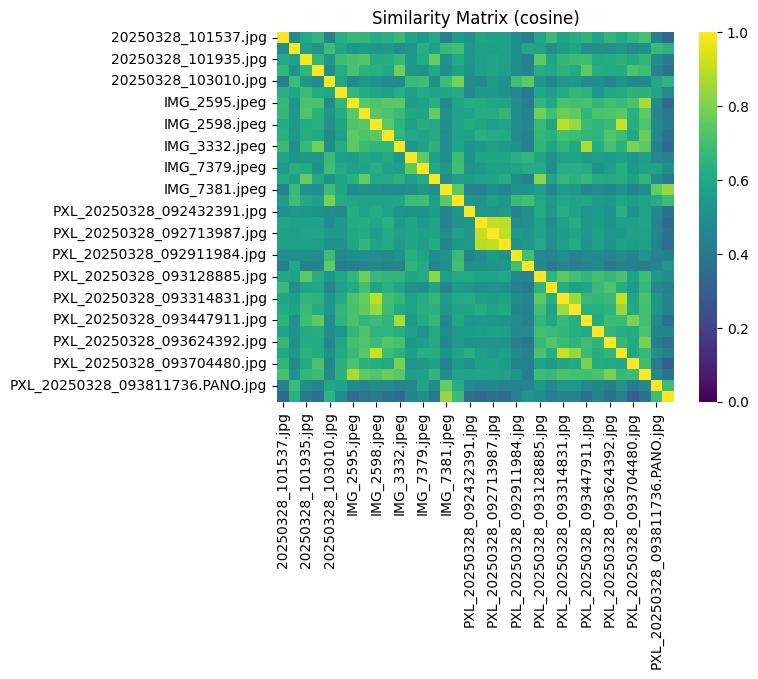

In [65]:
timings_list = []

for model_name in ['vit_base_patch14_dinov2', 'swin_tiny', 'vit_b16', 'mobilenet_v3_large', 'efficientnet_b0', 'resnet50']:
    print(f"--- Pipeline für {model_name} ---")
    df = run_pipeline_for_model(model_name, image_files, image_folder)
    timings_list.append(df)

all_timings_df = pd.concat(timings_list, ignore_index=True)

Es fällt direkt auf, dass ViT tatsächlich sehr viel länger brauchen als die CNNs die Pipline zu durchlaufen
gerade "vit_base_patch14_dinov2" benötigt sehr lange.


In [66]:
df = all_timings_df.copy()

In [67]:
df["step"].value_counts()

step
image_load_and_preprocess              204
embedding_extract                      204
model_load                               6
similarity_matrix_and_visualization      6
Name: count, dtype: int64

In [68]:
# mittelwert der zeit pro model berechnen
embedding_mean = df[df["step"] == "embedding_extract"].groupby("model")["duration_sec"].mean()

mean_rows = pd.DataFrame({
    "model": embedding_mean.index,
    "step": "embedding_extract_mean",
    "duration_sec": embedding_mean.values
})

df = pd.concat([df, mean_rows], ignore_index=True)
df = df[df["step"] != "embedding_extract"]
# sortieren 
df = df.sort_values(by = "duration_sec")


In [69]:
df[df["step"]=="model_load"]

,model,step,duration_sec
210,mobilenet_v3_large,model_load,0.126278
280,efficientnet_b0,model_load,0.198186
350,resnet50,model_load,0.448845
70,swin_tiny,model_load,0.816373
0,vit_base_patch14_dinov2,model_load,1.803091
140,vit_b16,model_load,1.863490


In [70]:
df[df["step"]=="embedding_extract_mean"]

,model,step,duration_sec
421,mobilenet_v3_large,embedding_extract_mean,0.024426
420,efficientnet_b0,embedding_extract_mean,0.043341
422,resnet50,embedding_extract_mean,0.095531
423,swin_tiny,embedding_extract_mean,0.128274
424,vit_b16,embedding_extract_mean,0.247698
425,vit_base_patch14_dinov2,embedding_extract_mean,1.780729


In [71]:
df[df["step"]=="similarity_matrix_and_visualization"]

,model,step,duration_sec
349,efficientnet_b0,similarity_matrix_and_visualization,0.324275
279,mobilenet_v3_large,similarity_matrix_and_visualization,0.326070
419,resnet50,similarity_matrix_and_visualization,0.336996
139,swin_tiny,similarity_matrix_and_visualization,0.351244
69,vit_base_patch14_dinov2,similarity_matrix_and_visualization,0.404315
209,vit_b16,similarity_matrix_and_visualization,0.430313


# Erkenntnisse: 
(code wurde anschließend erneut durchgeführt, deshalb stimmen durations evtl. nicht mehr 1 zu 1)
<br> tatsächlich brauchen die ViT Modelle sehr viel länger als die CNNs:
sowohl beim laden als auch beim extrahieren der features

| model                   | step                  | duration_sec |
|-------------------------|-----------------------|--------------|
| mobilenet_v3_large      | model_load            | 0.137734     |
| efficientnet_b0         | model_load            | 0.147844     |
| resnet50                | model_load            | 0.426040     |
| swin_tiny               | model_load            | 0.797757     |
| vit_b16                 | model_load            | 1.588772     |
| vit_base_patch14_dinov2 | model_load            | 1.640286     |

<br>

| model                   | step                  | duration_sec |
|-------------------------|-----------------------|--------------|
| mobilenet_v3_large      | embedding_extract_mean| 0.027631     |
| efficientnet_b0         | embedding_extract_mean| 0.038631     |
| resnet50                | embedding_extract_mean| 0.096161     |
| swin_tiny               | embedding_extract_mean| 0.104732     |
| vit_b16                 | embedding_extract_mean| 0.234720     |
| vit_base_patch14_dinov2 | embedding_extract_mean| 1.796305     |


Die beiden top performern in der Zeit sind mobilenet_v3_large und efficientnet_b0

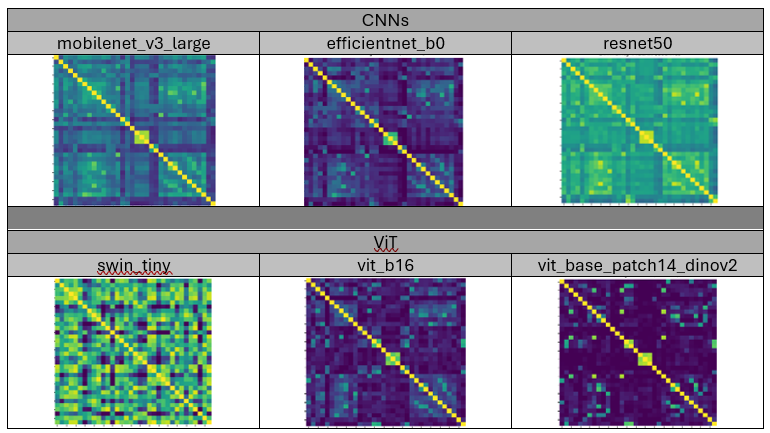


da die ViTs alle sehr lange brauchen, können diese direkt ausgeschlossen werden.
Ein interessantes Detail ist allerdings, das vor allem vit_base_patch14_dinov2 tatsächlich am genausen arbeitet, hier ist klar anhand der heatmap zu erkennen wo Bilder mit ähnlichem Motiv sind, und welche nicht das richtige motiv haben.
swin_tiny scheint nicht sehr gut zu erkennen um welche Motive es sich handelt, überprüft an den Hydranten im Bilddatensatz. DIe Hydranten wurden nciht als ähnlich erkannt. Allgemein ist die Farbverteilung innerhalb der Heatmap auffällig anders als bei allen anderen Ähnlichkeitsmatritzen. Vielleicht ein Fehler in meiner Implementierung. Da das Model aber sowieso zu lange braucht, fällt es raus.

Bei den CNNs:
Die Matrix von Resnet ist am hellsten und mit den geringsten werteintervall. was bedeutet das alle bilder sehr ähnlich erscheinen, es wurden also oft gleiche Motive erkannt. obwohl die Bilder klar unterschiedlich sind und größere differenzen gefunden hätten werden können.
efficientnet_b0 ist nur wenige sekunden langsamer als mobilenet_v3_large.
mobilenet_v3_large scheint auch ein bisschen generrellere embeddings zu finden, da auch diese Ähnlichkeitswerte allgemein etwas höher sind als die von efficientnet_b0, der unterschied wirkt aber nicht sehr signifikant.
Ich entscheide mich deshlab für mobilenet_v3_large

### sonstiges
bei der ausgabe der genauen Klassen die erkannt wurden fällt außerdem auf, dass oft mehrere klassen erkannt werden, die nicht exact dem Bild entsprechen.
Für ähnliche Bilder werden aber ähnliche "falsche" Klassen erkannt. Wie zum Beispiel der Dishwasher für die Bilder mit Geschirr
(ich persönlich finde es aber nachvollziehbar wieso es als dishwasher klassifiziert wird..)
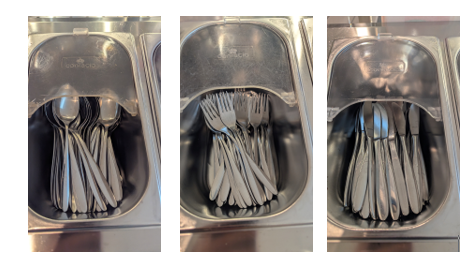

Oder auch Blumen, die alle als u.a. als Daisy klassifiziert werden auch bei einer Sonnenblume

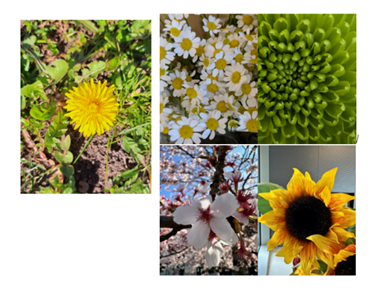


# Final Code

In [78]:
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
import os
import torch
import numpy as np

def get_preprocess_mobilenet():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

def extract_embeddings_from_folder(image_folder):
    model = models.mobilenet_v3_large(pretrained=True)
    preprocess = get_preprocess_mobilenet()
    
    embeddings = []
    filenames = []
    
    for img_file in os.listdir(image_folder):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(image_folder, img_file)
        img = Image.open(img_path).convert('RGB')
        input_tensor = preprocess(img).unsqueeze(0)
        
        embedding = extract_embedding_mobilenet(model, input_tensor)
        embeddings.append(embedding)
        filenames.append(img_file)
    
    df = pd.DataFrame({
        'filename': filenames,
        'embedding': embeddings
    })
    return df

def extract_embedding_mobilenet(model, input_tensor):
    model.eval()
    with torch.no_grad():
        features = model.features(input_tensor)
        embedding = torch.nn.functional.adaptive_avg_pool2d(features, 1).view(input_tensor.size(0), -1)
    return embedding.cpu().numpy()[0]

def normalize_embedding(emb):
    return emb / np.linalg.norm(emb)

def cosine_similarity(a, b):
    a_norm = a / np.linalg.norm(a)
    b_norm = b / np.linalg.norm(b)
    return np.dot(a_norm, b_norm)

def find_top5_similar_images(new_img_path, df_embeddings):
    model = models.mobilenet_v3_large(pretrained=True)
    preprocess = get_preprocess_mobilenet()
    
    img = Image.open(new_img_path).convert('RGB')
    input_tensor = preprocess(img).unsqueeze(0)
    embedding_new = extract_embedding_mobilenet(model, input_tensor)
    
    # Berechne Ähnlichkeiten
    similarities = df_embeddings['embedding'].apply(lambda emb: cosine_similarity(embedding_new, emb))
    
    # Top 5 Indexe mit höchsten Similarities
    top5_indices = similarities.nlargest(5).index
    
    return df_embeddings.loc[top5_indices]


def plot_similar_images(new_img_path, df_embeddings, similar_images_df, image_folder='images_'):
    model = models.mobilenet_v3_large(pretrained=True)
    preprocess = get_preprocess_mobilenet()
    
    new_img = Image.open(new_img_path).convert('RGB')
    input_tensor = preprocess(new_img).unsqueeze(0)
    embedding_new = extract_embedding_mobilenet(model, input_tensor)
    
    plt.figure(figsize=(15, 5))
    
    # Neues Bild
    plt.subplot(1, 6, 1)
    plt.imshow(new_img)
    plt.title("Neues Bild")
    plt.axis('off')
    
    # Für jedes der 5 ähnlichsten Bilder
    for i, row in enumerate(similar_images_df.itertuples(), start=2):
        sim_score = cosine_similarity(embedding_new, row.embedding)
        
        img_path = os.path.join(image_folder, row.filename)
        img = Image.open(img_path).convert('RGB')
        
        plt.subplot(1, 6, i)
        plt.imshow(img)
        plt.title(f"{row.filename}\nSimilarity: {sim_score:.3f}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [79]:
df_embeddings = extract_embeddings_from_folder('images_')

# Normiere alle Embeddings einzeln
df_embeddings['embedding'] = df_embeddings['embedding'].apply(normalize_embedding)


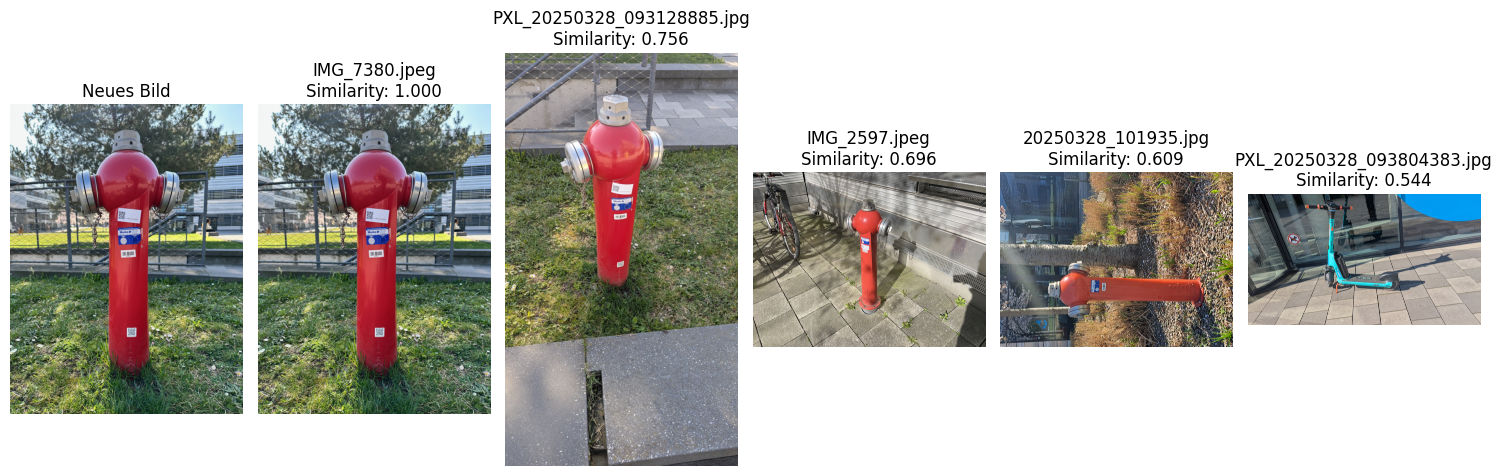

In [80]:
new_img_path = "IMG_7380.jpeg"
similar_images = find_top5_similar_images(new_img_path, df_embeddings)
plot_similar_images(new_img_path, df_embeddings, similar_images)

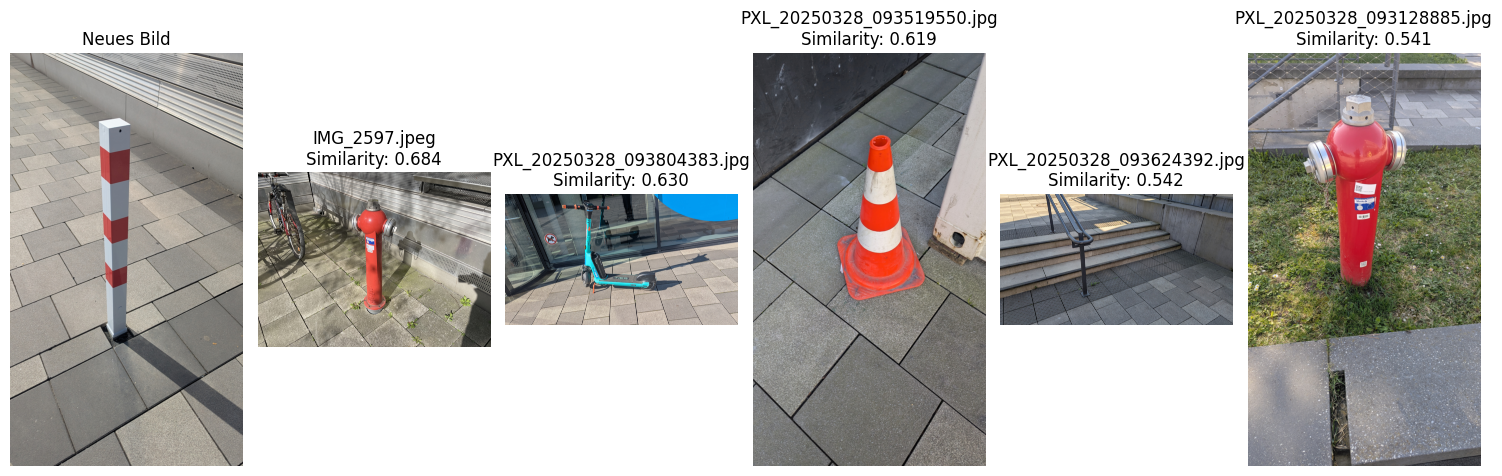

In [81]:
new_img_path = "PXL_20250328_092442823.jpg"
similar_images = find_top5_similar_images(new_img_path, df_embeddings)
plot_similar_images(new_img_path, df_embeddings, similar_images)

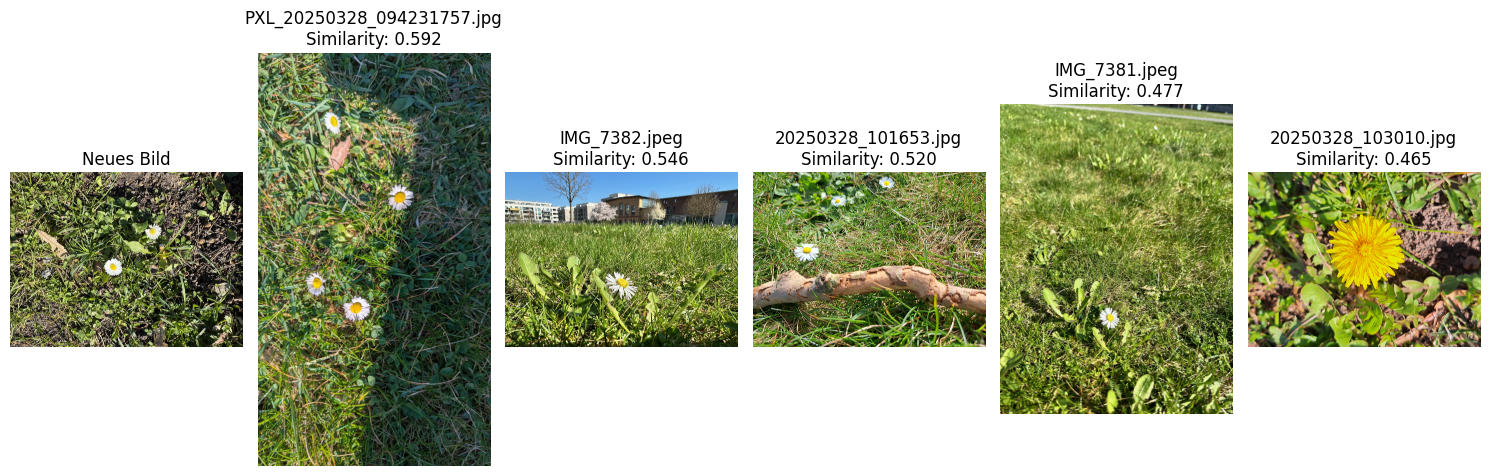

In [82]:
new_img_path = "IMG_3675.jpeg"
similar_images = find_top5_similar_images(new_img_path, df_embeddings)
plot_similar_images(new_img_path, df_embeddings, similar_images)